# Convolutional Neural Networks

            ## 1. Learning objectives

            - Compute a convolution by hand
- Track channel and spatial dimensions
- Train a compact CNN on digits

            ## 2. Prerequisites

            NumPy arrays, matrix multiplication, basic derivatives, and the supervised-learning workflow.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Python lesson ready; reproducible seed = 42
PyTorch: 2.14.0+cpu | device: cpu


## 3. Problem definition

            Recognize local image patterns while sharing the same detector across spatial positions.

            ## 4. Real-world use cases

            - Image recognition
- Sequence modeling
- Learned feature representations

            ## 5. Core intuition in simple language

            A small filter slides across an image; early filters detect edges and later layers combine local patterns.

## 6. Mathematical foundation

            $$Y_{i,j}=\sum_{u=0}^{h-1}\sum_{v=0}^{w-1}X_{i+u,j+v}K_{u,v}.$$

            **Every symbol:**

            - $X$ is the input image.
- $K$ is an h-by-w kernel.
- $Y_{i,j}$ is one output location.
- $u,v$ index the local patch.

            **Why the equation is needed:** Local weighted sums provide translation-aware feature detectors with far fewer parameters than a dense image layer.

            **Small numerical example:** For patch [[1,2],[3,4]] and kernel [[1,0],[0,-1]], output is 1-4=-3.

            **Connection to Python:** nn.Conv2d vectorizes this operation across batches, channels, and learned kernels.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Create tensors with explicit batch and feature dimensions
2. Run a forward pass
3. Compute a loss against targets
4. Backpropagate gradients
5. Update parameters with an optimizer
6. Evaluate on untouched validation data

## 9. Implementation from scratch

NumPy exposes the forward calculation and, where appropriate, the gradients.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def conv2d_single(image, kernel):
    out_h = image.shape[0] - kernel.shape[0] + 1
    out_w = image.shape[1] - kernel.shape[1] + 1
    output = np.empty((out_h, out_w))
    for row in range(out_h):
        for column in range(out_w):
            output[row, column] = np.sum(image[row:row+kernel.shape[0], column:column+kernel.shape[1]] * kernel)
    return output

image = np.arange(25, dtype=float).reshape(5, 5)
edge_kernel = np.array([[1., 0., -1.], [1., 0., -1.], [1., 0., -1.]])
feature_map = conv2d_single(image, edge_kernel)
print("Image/kernel/output:", image.shape, edge_kernel.shape, feature_map.shape)

Image/kernel/output: (5, 5) (3, 3) (3, 3)


## 10. Implementation using a standard library

PyTorch tensors, modules, autograd, losses, and optimizers provide the standard implementation.

## 11. Dataset loading and exploration

Every lesson uses a generated sequence or a small dataset bundled with scikit-learn; no download is required.

## 12. Data preprocessing

Splits occur before fitted transformations. Inputs are converted to float32 tensors and class labels to int64.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Model diagnostics: {'input_shape': (1347, 1, 8, 8), 'intermediate_shape': (1, 8, 8, 8), 'output_shape': (1347, 10), 'trainable_parameters': 3818, 'final_training_loss': 1.6809, 'final_validation_loss': 1.4985, 'validation_accuracy': 0.873}


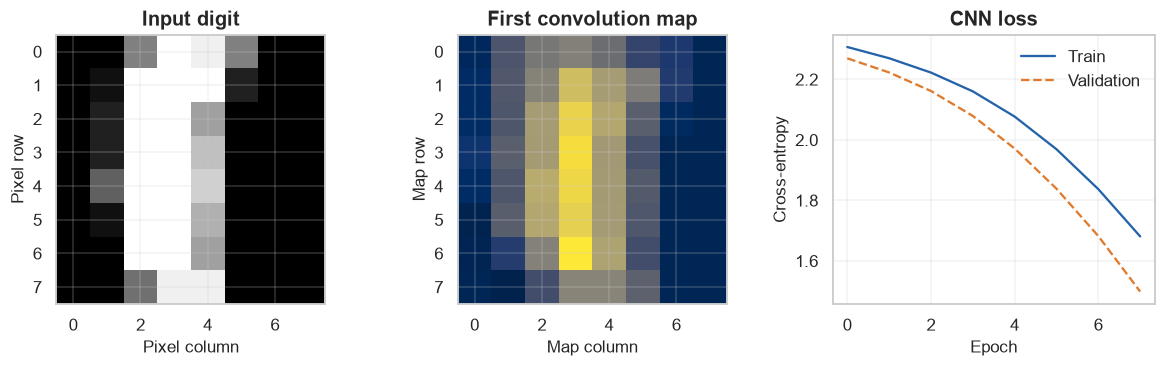

In [3]:
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

digits = load_digits()
X = (digits.images / 16.0).astype("float32")[:, None, :, :]
X_train, X_validation, y_train, y_validation = train_test_split(X, digits.target, test_size=.25, stratify=digits.target, random_state=RANDOM_SEED)
train_X = torch.tensor(X_train); train_y = torch.tensor(y_train, dtype=torch.long)
validation_X = torch.tensor(X_validation)
model = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(8, 16, kernel_size=3, padding=1), nn.ReLU(), nn.Flatten(),
    nn.Linear(16*4*4, 10),
)
optimizer = torch.optim.Adam(model.parameters(), lr=.01)
loss_fn = nn.CrossEntropyLoss()
train_losses=[]; validation_losses=[]
for epoch in range(8):
    model.train(); optimizer.zero_grad(); logits=model(train_X); loss=loss_fn(logits, train_y); loss.backward(); optimizer.step()
    model.eval()
    with torch.no_grad():
        val_logits=model(validation_X); val_loss=loss_fn(val_logits, torch.tensor(y_validation, dtype=torch.long))
    train_losses.append(loss.item()); validation_losses.append(val_loss.item())
prediction=val_logits.argmax(1).numpy()
with torch.no_grad():
    first_map=model[1](model[0](validation_X[:1]))
validation_accuracy = accuracy_score(y_validation,prediction)
print("Model diagnostics:", {
    "input_shape": tuple(train_X.shape),
    "intermediate_shape": tuple(first_map.shape),
    "output_shape": tuple(logits.shape),
    "trainable_parameters": sum(p.numel() for p in model.parameters()),
    "final_training_loss": round(train_losses[-1], 4),
    "final_validation_loss": round(validation_losses[-1], 4),
    "validation_accuracy": round(validation_accuracy, 3),
})
figure, axes=plt.subplots(1,3,figsize=(11,3.5))
axes[0].imshow(validation_X[0,0], cmap="gray"); axes[0].set(title="Input digit", xlabel="Pixel column", ylabel="Pixel row")
axes[1].imshow(first_map[0,0], cmap="cividis"); axes[1].set(title="First convolution map", xlabel="Map column", ylabel="Map row")
axes[2].plot(train_losses,label="Train",color=COURSE_COLORS["blue"]); axes[2].plot(validation_losses,label="Validation",color=COURSE_COLORS["orange"],linestyle="--")
axes[2].set(title="CNN loss",xlabel="Epoch",ylabel="Cross-entropy"); axes[2].legend()
figure.tight_layout(); plt.show()

**How to interpret the result:** The feature map shows one learned local response; the loss curves and validation accuracy evaluate the full classifier.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Kernel size changes local context and parameter count; stacking small kernels often provides efficient larger receptive fields.

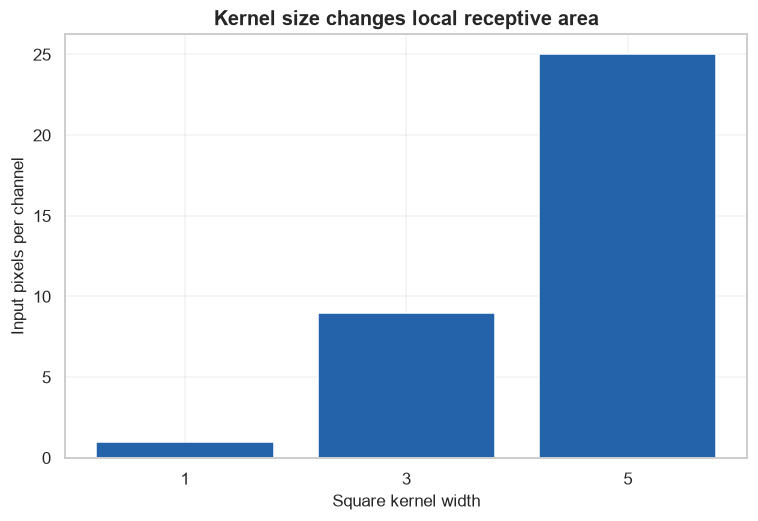

In [4]:
kernel_sizes=[1,3,5]
receptive_areas=[value**2 for value in kernel_sizes]
figure,axis=plt.subplots()
axis.bar([str(value) for value in kernel_sizes],receptive_areas,color=COURSE_COLORS["blue"])
axis.set(title="Kernel size changes local receptive area",xlabel="Square kernel width",ylabel="Input pixels per channel")
plt.show()

## 18. Common mistakes

            - Forgetting batch and feature dimensions
- Applying softmax before CrossEntropyLoss
- Evaluating on the training set
- Leaving gradients accumulated between optimizer steps

            ## 19. Advantages and disadvantages

            **Advantages**

            - Learns features jointly with predictions
- Flexible building blocks for structured data

            **Disadvantages**

            - Needs careful optimization and validation
- Can be computationally expensive and difficult to interpret

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the data and task benefit from learned nonlinear representations and validation supports the added complexity.

            **Do not use it when:** a small tabular dataset is handled well by a simpler, easier-to-audit model.

## 21. Exercises

1. **Conceptual:** Why do hidden layers need nonlinear activations?
2. **Mathematical/hand calculation:** Calculate ReLU([−2, 0, 3]).
3. **Coding/experimentation:** Double hidden width and compare parameter count and validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Without nonlinearities, multiple affine layers equal one affine layer.
2. The result is [0, 0, 3].
3. Change the layer width, count parameters, retrain with the same split, and compare training-versus-validation loss rather than training loss alone.

</details>

## 23. Summary and key takeaways

            - Tensor shapes are part of the model specification
- Forward propagation produces predictions and backpropagation produces gradients
- Training and validation curves reveal optimization and generalization

            ## 24. Further reading

            - [PyTorch tutorials](https://pytorch.org/tutorials/)
- [PyTorch neural-network modules](https://pytorch.org/docs/stable/nn.html)